In [1]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np


Instructions for updating:
non-resource variables are not supported in the long term


합성곱 신경망(Convolutional Neural Network, CNN)

시각적 이미지나 영상 등의 데이터를 분석하고 처리하는 데 특화된 대표적인 딥러닝 알고리즘입니다. 인간의 뇌가 시각 정보를 받아들이는 방식을 모방해서 만들어졌다.

MNIST 손글씨 데이터를 내려받아 학습 데이터와 테스트 데이터로 분리해서 저장한다.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

학습 데이터를 학습 데이터(x_train)와 검증 데이터(x_val)로 분리하기

In [3]:
x_val = x_train[50000:] # 6만개의 학습 데이터에서 검증 데이터로 사용할 1만개를 저장한다.
x_train = x_train[:50000] # 6만개의 학습 데이터에서 학습 데이터로 사용할 5만개를 저장한다.
y_val = y_train[50000:] # 검증 데이터의 레이블
y_train = y_train[:50000] # 학습 데이터의 레이블

In [4]:
print(f'x_train.shape: {x_train.shape}, y_train.shape: {y_train.shape}')
print(f'x_val.shape: {x_val.shape}, y_val.shape: {y_val.shape}')
print(f'x_test.shape: {x_test.shape}, y_test.shape: {y_test.shape}')

x_train.shape: (50000, 28, 28), y_train.shape: (50000,)
x_val.shape: (10000, 28, 28), y_val.shape: (10000,)
x_test.shape: (10000, 28, 28), y_test.shape: (10000,)


학습 데이터를 출력해보면 데이터가 0부터 255사이의 숫자로 구성된 것을 확인할 수 있다.

In [5]:
print(y_train[:10])
for row in x_train[0]:
    for i in row:
        print('{:3d} '.format(i), end='')
    print()

[5 0 4 1 9 2 1 3 1 4]
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   

컴퓨터 비전에서 많이 사용되는 딥러닝 모델인 CNN의 장점은 다층 퍼셉트론과 비교하면 쉽게 알 수 있다.

다층 퍼셉트론의 첫 번째 단점은 이미지의 고유한 생김새를 사용할 수 없다는 것이다.  
다층 퍼셉트론의 경우 2차원 데이터를 입력할 수 없으므로 이미지 데이터를 입력하기위해서 2차원 평면에 있는 숫자 이미지를 1차원 배열로 변환해야 한다.  
1차원 배열로 변환된 이미지 데이터는 원래 숫자 이미지를 떠올리기 쉽지않다. 1차원으로 변환된 이미지 데이터를 입력받은 다층 퍼셉트론의 경우, 이미지가 2차원 평면에서 가지고 있던 모양(지역) 정보를 잃어버린 채 학습을 시작한다.

두 번째 단점은 다층 퍼셉트론은 픽셀 하나 하나의 변화에 상당히 민감하다는 것이다.  
이미지의 생김새 정보를 사용할 수 없는 다층 퍼셉트론은 가지고 있는 정보가 픽셀 정보밖에 없기 때문에 한 두 개 차이가 모델 예측에 큰 영향을 끼치게 된다.

세 번째 단점은 다층 퍼셉트론은 픽셀 한 두 개의 정보에도 민감하게 반응하기때문에 상당히 많은 변수를 모델안에 가지고 있다는 것이다. 이로인해 모델의 크기를 크게 만들고, 학습 시간이 오래 걸리며, 자칫 잘못하면 과적합된 모델이 되기쉽다.

생김새 정보 획득하기

<img src="./CNN1.png" wigth="1300" align="left" />

두 개의 비슷한 생김새의 숫자 2가 있을때 전체적인 생김새는 생김새는 달라도 머리와 꼬리 부분이 있고 머리와 꼬리를 이어주는 대각선이 있다면 단번에 숫자 2임을 판별할 수 있다.

CNN은 어떻게 특징을 찾아내는가?

<img src="./CNN2.png" wigth="1300" align="left" />

위의 그림에서 필터 또는 커널이라고 불리는 반투명한 네모 상자가 이미지 왼쪽 최상단에서 일정한 간격으로 이동하면서 오른쪽 최하단까지 이동한다. 이처럼 필터를 이동하는 기법을 스트라이드(stride)라고 한다.  
필터는 이미지의 특징을 추출하기 위한 네모 상자이고 이 필터와 겹치는 이미지 부분을 수용 영역이라 부른다.

아래 그림에서 대각선 필터는 숫자 2로 부터 두 곳의 대각선 특징을 발견한다. 그러나 숫자 1에서는 대각선 특징을 발견하지 못한다.

<img src="./CNN3.png" wigth="1300" align="left" />

모든 딥러닝 모델이 그렇듯이 CNN 모델 역시 수학적인 모델이다. 필터가 어떻게 특징을 추출하는지 알아보자.  
MNIST 숫자 데이터는 흑백 이미지로 각 픽셀은 0부터 255 사이의 값 중 하나를 가지고 있다. 픽셀 안의 숫자 0은 흰색을 의미하고 255는 검은색을 의미한다. 그리고 그 사이의 숫자는 검은색과 흰색 사이의 어떤 색(회색)을 의미한다.  
만약 이미지 안에 오직 흰색과 검은색만 존재한다면 아래 그림과 같이 0과 255로만 구성되어 있을 것이다.

<img src="./CNN4.png" wigth="1300" align="left" />

위의 그림에서 알 수 있듯이 필터 안에는 특정한 숫자가 들어있고 필터와 이미지가 겹치는 부분마다 곱셈이 이루어지고 필터에 4개의 픽셀이 있다면 4개 영역이 곱해지고 곱해진 값은 최종적으로 더해진다. 최종값이 크다는 의미는 필터와 겹쳐진 부분이 많다는 의미이며 반대로 최종값이 작을 경우 겹쳐지는 부분이 적었다라고 해석할 수 있다.

CNN 모델안에서 각 특성의 개수만큼 필터가 필요하다.  
보통 전반부에 존재하는 필터는 직선, 곡선 같은 기초적인 특성을 구별하기 위해 존재하고 후반부에 존재하는 필터는 동그라미, 세모 같은 좀 더 고차원의 특징을 구분하기 위해 존재한다.  
필터를 사용해서 모든 특징을 찾아낸 후, 이 특징들은 다중 퍼셉트론의 입력값으로 들어가서 필터로 부터 구별된 특징을 기반으로 숫자 분류를 진행한다.

<img src="./CNN5.png" wigth="1300" align="left" />

필터를 스트라이드를 통해 얻어진 행렬을 피쳐 맵(feature map)이라고 한다.  
피쳐 맵을 활성화 함수에 넣어 구현한 행렬을 액티베이션 맵(activation map)이라고 한다.

맥스 풀링(max pooling)은 지정된 영역에서 가장 큰 수치를 선택하고 나머지는 버린다.  
아래 그림은 2 * 2 필터에 스트라이드를 적용한 피쳐 맵에 맥스 풀링을 적용한 예이다.  
피쳐 맵의 크기가 줄어듬으로써 얻는 장점은 계산에 사용하는 파라미터의 개수가 줄어들어 계산 속도가 빨라지고 파라미터를 줄임으로써 모델의 분산을 줄이고 그에 따라 과적합 가능성을 줄여준다.

<img src="./CNN6.png" wigth="1300" align="left" />

제로 패딩(zero padding)은 0으로 입력 행력의 테두를 감싸주는 기술이다.  
스트라이드를 통해 입력된 행렬보다 작아진 행렬이 출력되고 작아진 만큼 정보 손실이 발생되므로 제로 패딩을 통해 입력 행렬의 크기를 크게 함으로써 스트라이드 이후에도 이미지 크기를 동일하게 유지할 수 있다.

<img src="./CNN7.png" wigth="1300" align="left" />

제로 패딩으로 인해 스트라이드 할 공간이 더 많아졌다. 만약 필터 크기가 3 * 3이고 스트라이드를 1픽셀씩 할 경우 피쳐 맵은 5 * 5로 제로 패딩을 하기 전의 입력과 동일한 크기로 출력될것이다.

데이터 구조를 변경한다.  
28 * 28 픽셀의 단색 이미지이므로 데이터의 형태를 28 * 28 * 1로 맞춰준다.

In [6]:
# CNN 모델에 입력하기 위해 데이터셋을 생성한다.
x_train = np.reshape(x_train, [50000, 28, 28, 1])
print(f'x_train.shape: {x_train.shape}')
x_val = x_val.reshape(10000, 28, 28, 1)
print(f'x_val.shape: {x_val.shape}')
x_test = x_test.reshape(-1, 28, 28, 1)
print(f'x_test.shape: {x_test.shape}')

x_train.shape: (50000, 28, 28, 1)
x_val.shape: (10000, 28, 28, 1)
x_test.shape: (10000, 28, 28, 1)


데이터 정규화

In [7]:
x_train = x_train.astype(np.float32)
x_train /= 255
x_val = x_val.astype(np.float32)
x_val /= 255
x_test = x_test.astype(np.float32)
x_test /= 255

손실 함수에서 크로스 엔트로피를 계산하기 위해 레이블을 원-핫 인코딩으로 변경한다.

In [8]:
y_train = tf.keras.utils.to_categorical(y_train, len(set(y_train)))
y_val = tf.keras.utils.to_categorical(y_val, len(set(y_val)))
y_test = tf.keras.utils.to_categorical(y_test, len(set(y_test)))

tensorflow로 CNN 구현하기

<img src="./CNN8.png" wigth="1400" align="left" />

MNIST 데이터 형태 그대로 28 * 28의 포맷을 입력 데이터로 사용하고 레이블은 0에서 9 사이의 숫자이다.

In [9]:
X = tf.placeholder(dtype=tf.float32, shape=[None, 28, 28, 1]) # 피쳐(x_train, x_val, x_test)를 기억할 placeholder
Y = tf.placeholder(dtype=tf.float32, shape=[None, 10]) # 레이블(y_train, y_val, v_test)를 기억할 placeholder

random_normal()와 truncated_normal() 메소드는 매우 비슷하게 작동하지만 큰 차이가 있다.  
두 메소드는 모두 정규 분포에 따른 랜덤한 값을 얻어오는데 random_normal() 메소드는 너무 작거나 너무 큰 값을 랜덤하게 가져올 수 있다.  
머신러닝이나 딥러닝 작업 중 너무 큰 가중치(기울기 폭주) 값이나 너무 작은 가중치(기울기 소멸) 값이 들어오면 작동을 멈춰버리는 현상이 발생되는데 이를 해결하기 위한 방법으로 너무 크거나 너무 작은 값을 랜덤값으로 가져오지 않는 truncated_normal() 메소드를 사용해서 난수를 발생시켜 사용한다.

In [10]:
import matplotlib.pyplot as plt

In [11]:
n = 1000000
A = tf.random_normal([n])
B = tf.truncated_normal((n,), stddev=1) # stddev 속성으로 난수가 발생되는 범위를 설정할 수 있다. 기본값은 1이다.

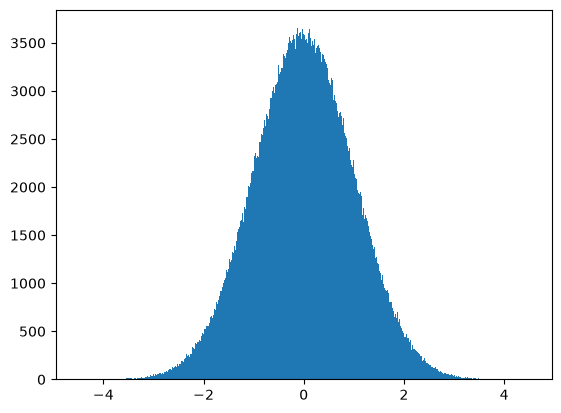

In [12]:
with tf.Session() as sess:
    a = sess.run(A)
    plt.hist(a, 1000, (-4.5, 4.5))

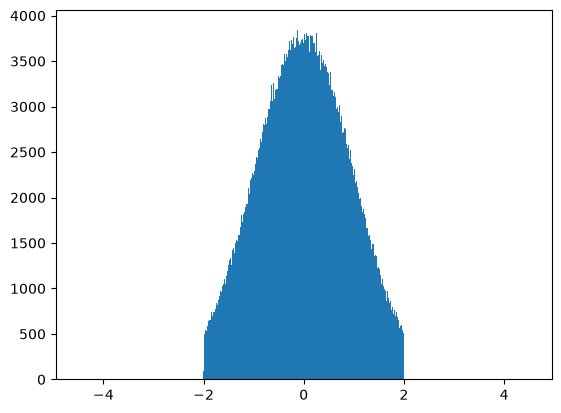

In [13]:
with tf.Session() as sess:
    b = sess.run(B)
    plt.hist(b, 1000, (-4.5, 4.5))

파라미터(필터, 바이어스)의 초기값을 설정한다.

truncated_normal() 메소드는 0에서 거리가 아주 먼 값이 난수로 선택되지 않게 도와준다.  
0에서 거리가 먼 값을 제외시키는 이유는 소프트 맥스 안의 시그모이드 함수의 특성 때문인데 시그모이드 함수 같은 경우 입력값이 매우 크거나 매우 작으면 그 미분값이 0과 가까워져서 경사 하강법으로 파라미터를 변경하기 어려워진다.

In [14]:
# shape를 넘겨받아 필터를 만들어 리턴하는 함수
def weight_variable(shape):
    initial = tf.truncated_normal(shape, stddev=1)
    return tf.Variable(initial)

In [15]:
# shape를 넘겨받아 바이어스를 만들어 리턴하는 함수
def bias_variable(shape):
    initial = tf.constant(0.1, shape=shape)
    return tf.Variable(initial)

In [16]:
with tf.Session() as sess:
    w = weight_variable([2, 1])
    b = bias_variable([2])
    sess.run(tf.global_variables_initializer())
    print(sess.run(w), sess.run(b))

[[-0.43186858]
 [-0.3821744 ]] [0.1 0.1]


컨볼루션 레이어를 만드는 함수를 만든다.

conv2d(input, filter, strides, padding) 메소드로 이미지 데이터에 패딩을 적용한 후 필터를 스트라이드 만큼 적용한다. 합성곱 연산  
input: 이미지 데이터  
filter: 합성곱에 사용할 필터  
strides: 필터가 움직이는 간격으로 1번째와 4번째 값은 통상적으로 1을 사용하고 2번째 값은 가로 스트라이드 값, 3번째 값은 세로 스트라이드 값을 지정한다.  
padding: 입력 데이터 행렬 주위를 0으로 감싸서 필터를 스트라이드 만큼 돌려서 나온 피쳐 맵의 크기가 작아지는 것을 방지하고 과적합이 발생하는 것을 방지할 수 있다.  
&nbsp;&nbsp;&nbsp;&nbsp;▶ SAME: 패딩 적용, 패딩을 적용해서 입력과 출력의 크기를 같게한다.  
&nbsp;&nbsp;&nbsp;&nbsp;▶ VALID: 패딩 미적용, 패딩을 적용하지 않아서 입력보다 출력의 크기가 작아진다.

In [17]:
# 필터를 적용할 이미지 데이터와 필터를 넘겨받아 컨볼루션 레이어를 만들어 리턴하는 함수
def conv2d(X, _filter):
    return tf.nn.conv2d(input=X, filter=_filter, strides=[1, 1, 1, 1], padding='SAME')

맥스 풀링 레이어를 만드는 함수를 만든다.

max_pool(value, ksize, strides, padding) 메소드로 맥스 풀링을 적용한다.  
value: 활성화 함수로 ReLU를 적용한 맥스 풀링을 적용할 데이터  
ksize: 맥스 풀링의 크기로 1번째와 4번째 값은 통상적으로 1을 사용하고 2번째 값은 맥스 풀링의 가로 크기, 3번째 값은 맥스 풀링 세로 크기를 지정한다.  
strides, padding는 conv2d() 메소드와 의미가 같다.

In [18]:
# 맥스 풀링을 적용할 데이터를 넘겨받아 맥스 풀링을 실행해서 리턴하는 함수
def max_pool(value):
    return tf.nn.max_pool(value=value, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

1번째 컨볼루션 레이어를 만든다.

In [19]:
# 1번째 컨볼루션 레이어는 16개의 필터(출력, 뉴런)를 가지고 있고 필터 크기는 5 * 5이고 바이어스는 필터의 개수만큼 만든다.
# [필터의 가로 크기, 필터의 세로 크기, 입력 개수, 필터(출력, 뉴런) 개수]
W_conv1 = weight_variable([5, 5, 1, 16]) # 1번째 컨볼루션 레이어의 필터 정의
B_conv1 = bias_variable([16]) # 1번째 컨볼루션 레이어의 바이어스 정의

# 컨볼루션 레이어(피쳐 맵)를 만들고 활성화 함수로 ReLU를 사용해서 액티베이션 맵을 만든다.
H_conv1 = tf.nn.relu(conv2d(X, W_conv1) + B_conv1)

# 1번째 컨볼루션 레이어의 출력에 맥스 풀링 레이어를 적용해서 액티베이션 맵의 크기를 줄여준다.
# 액티베이션 맵의 크기를 줄여줌으로써 파라미터가 줄어들어 모델의 크기가 작아지고 과적합의 위험도 줄여준다.
H_pool1 = max_pool(H_conv1)
# 맥스 풀링 레이어에 의해서 액티베이션 맵의 크기가 14 * 14가 되었고 이 값은 2번째 컨볼루션 레이어의 입력으로 들어간다.

2번째 컨볼루션 레이어를 만든다.

In [20]:
# 2번째 컨볼루션 레이어는 32개의 필터(출력, 뉴런)를 가지고 있고 필터 크기는 5 * 5이고 바이어스는 필터의 개수만큼 만든다.
W_conv2 = weight_variable([5, 5, 16, 32]) # 2번째 컨볼루션 레이어의 필터 정의
B_conv2 = bias_variable([32]) # 2번째 컨볼루션 레이어의 바이어스 정의
# 컨볼루션 레이어(피쳐 맵)를 만들고 활성화 함수로 ReLU를 사용해서 액티베이션 맵을 만든다.
H_conv2 = tf.nn.relu(conv2d(H_pool1, W_conv2 + B_conv2))
# 2번째 컨볼루션 레이어의 출력에 맥스 풀링 레이어를 적용해서 액티베이션 맵의 크기를 줄여준다.
H_pool2 = max_pool(H_conv2)
# 맥스 풀링 레이어에 의해서 액티베이션 맵의 크기가 7 * 7가 되었고 이 값은 FC(Fully Connected) 레이어의 입력으로 들어간다.

FC(Fully Connected) 레이어를 만든다.

FC 영역에는 FC1, FC2 총 2개의 히든 레이어가 존재하고 FC1은 128개의 노드, FC2는 10개의 노드가 존재한다.  
FC2에 10개의 노드가 존재하는 이유는 FC2에 10개 노드의 값들을 소프트 맥스에 입력해서 각 노드별 확률을 구하기 위해서이다.  
각 노드의 숫자는 0부터 9를 의미하며, 이 예측값은 크로스 엔트로피를 통해서 레이블과의 차이를 계산하는데 사용한다.

In [22]:
# FC 레이어는 컨볼루션 레이어 1, 2를 통해 추출된 이미지의 특징을 입력으로 받아서 0부터 9 사이의 숫자 중 하나로 이미지를 분류한다.
W_fc1 = weight_variable([7 * 7 * 32, 128]) # 1번째 FC 레이어의 가중치 정의
B_fc1 = bias_variable([128]) # 1번째 FC 레이어의 바이어스 정의

# 2번째 컨볼루션 레이어의 맥스 풀링 결과를 행과 열을 변경해서 가중치와 행렬의 내적을 이용해 계산하고 활성화 함수는 ReLU를 사용한다.
H_pool_flat = tf.reshape(H_pool2, [-1, 7 * 7 * 32])
H_fc1 = tf.nn.relu(tf.matmul(H_pool_flat, W_fc1) + B_fc1)

W_fc2 = weight_variable([128, 10]) # 2번째 FC 레이어의 가중치 정의
B_fc2 = bias_variable([10]) # 2번째 FC 레이어의 바이어스 정의
Y_conv = tf.matmul(H_fc1, W_fc2) + B_fc2

손실 함수와 옵티마이저를 정의한다.